### Figure 4F. Does long theta or remote theta content help improve choice accuracy on top of the change of mind decision?

Oct 23, 2025

In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [4]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

from spyglass.shijiegu.changeOfMind_figures.extra_correctness import (
                figure4_correctness,
                model2numbers,
                has_remote_theta, has_outer_remote_theta,
                has_home_remote_theta, has_long_theta)

[2026-05-02 16:58:06,725][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[16:58:21][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:58:21][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:58:21][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:58:22][WARNING] Spyglass: Deprecation: this class has b

In [5]:
list_of_days_animals, learning_flag, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}, {}

In [6]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
learning_flag[animal] = [1,1,1,1,0] #denote for each day, if it is a learning day
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
learning_flag[animal] = [1,1,1,1,1,0] #denote for each day, if it is a learning day
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
learning_flag[animal] = [1,1,1,1,1,1,0,0,0] #denote for each day, if it is a learning day
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
learning_flag[animal] = [1 for d in ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806']] #denote for each day, if it is a learning day
learning_flag[animal] += [0 for d in ['20230807','20230808','20230809','20230810','20230811']]
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
learning_flag[animal] = [1 for d in ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107']]
learning_flag[animal] += [0 for d in ['20231108']]

seq_animals[animal] = 'rev2'

### Simple conditioning

In [7]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta

from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm



In [8]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

### 1. Parse data for plotting

In [40]:
#parameter_name_long_theta = "params_both_max_segment_all_maze_2_state"
#parameter_name_remote = "params_both_max_all_maze_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

success = figure4_correctness(
    output_folder,
    list_of_days_animals, learning_flag,
    parameter_name_long_theta = parameter_name_long_theta,
    parameter_name_remote = parameter_name_remote,
    minimum_duration_long = minimum_duration_long,
    minimum_duration_remote = minimum_duration_remote,
    min_posterior = min_posterior,
    sd = sd,
    hpd = hpd)

molly20220416_.nwb
molly20220417_.nwb
remote_content [4, 4, 4, 4, 4]
remote_content [3]
remote_content [4, 4]
remote_content [4, 0, 0, 4, 4, 4]
molly20220418_.nwb
remote_content [4]
remote_content [4]
remote_content [4, 4]
remote_content [4]
remote_content [0, 0]
remote_content [4]
remote_content [1]
remote_content [4, 4]
molly20220419_.nwb
remote_content [0]
remote_content [4]
remote_content [4]
remote_content [3]
remote_content [1]
molly20220420_.nwb
remote_content [2, 2]
remote_content [0]
remote_content [2]
remote_content [0]
remote_content [0, 0]
Data successfully pickled and saved.
klein20231101_.nwb
remote_content [1, 3, 4]
remote_content [3, 4, 3]
remote_content [3]
remote_content [3]
remote_content [3, 4, 4, 4, 4]
remote_content [2]
remote_content [3]
remote_content [3, 3, 0]
remote_content [0, 1, 3]
remote_content [3]
remote_content [0]
remote_content [4, 3]
remote_content [3, 1, 3]
remote_content [4, 4]
remote_content [2, 2, 2]
remote_content [3, 2]
remote_content [1]
remote

In [41]:
success

{'molly': 1, 'klein': 1, 'eliot': 1, 'julio': 1, 'lewis': 1}

### 1. Basic conditioning plot

In [9]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table, alternative = "greater")
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value



In [10]:
#parameter_name_long_theta = "params_both_max_segment_all_maze_2_state"
#parameter_name_remote = "params_both_max_all_maze_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"

#parameter_name = "params_both_max_run_time_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat M: 0.2727272727272727 remote trials with home.
pvalue molly row number 0 0.24653358136178588
pvalue molly row number 1 0.6639434716719794
pvalue molly row number 2 0.038247793396534814
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat E: 0.3157894736842105 remote trials with home.
pvalue eliot row number 0 0.11190699424990957
pvalue eliot row number 1 0.17386007454156152
pvalue eliot row number 2 0.39572782324682704
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat J: 0.5517241379310345 remote trials with home.
pvalue julio row number 0 0.0484399380732574
pvalue julio row number 1 0.336978781260

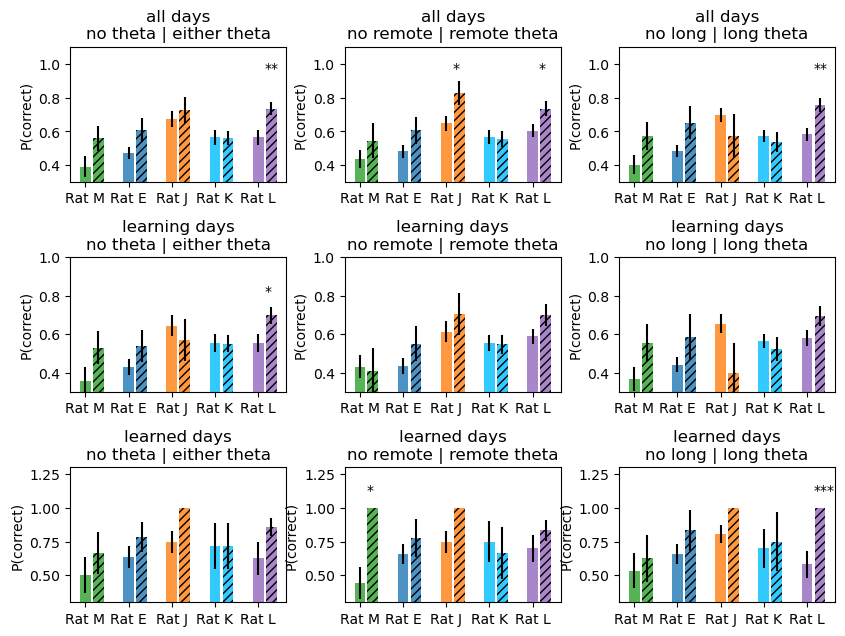

In [44]:
num_of_panels = 3
draw_text = False
fig, axes = plt.subplots(3, num_of_panels, figsize=(3 * num_of_panels, 7))#sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]#["molly","eliot","julio","lewis","klein"]#["molly","lewis","julio","klein"]

annotations = {(i,j):[] for j in range(3) for i in range(3)}

for animal in animals:

    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward,
     remote_theta, long_theta, theta, theta_home,
     com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"], loaded_data["remote_theta_home"],
        loaded_data["com_num"], loaded_data["learning_flag"])
    
    print(f"Rat {animal[0].upper()}: {np.sum(np.array(remote_theta)[np.array(theta_home) > 0])/np.sum(remote_theta)} remote trials with home.")

    for axes_row_ind in [0,1,2]: #all data, learning days, post-learning days
        
        if axes_row_ind == 0:
            reward_theta = np.array(reward)[np.array(theta) > 0]
            reward_nontheta = np.array(reward)[~(np.array(theta) > 0)]
            reward_remote_theta = np.array(reward)[np.array(remote_theta) > 0]
            reward_nonremote_theta = np.array(reward)[~(np.array(remote_theta) > 0)]
            reward_long_theta = np.array(reward)[np.array(long_theta) > 0]
            reward_nonlong_theta = np.array(reward)[~(np.array(long_theta) > 0)]
        elif axes_row_ind == 1:
            learning = np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, learning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, learning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, learning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, learning)]
            reward_nonremote_theta = np.array(reward)[np.logical_and((1-np.array(remote_theta)) > 0, learning)]
            reward_nonlong_theta = np.array(reward)[np.logical_and((1-np.array(long_theta)) > 0, learning)]
        elif axes_row_ind == 2:
            nonlearning = 1 - np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, nonlearning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, nonlearning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, nonlearning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, nonlearning)]
            reward_nonremote_theta = np.array(reward)[np.logical_and((1-np.array(remote_theta)) > 0, nonlearning)]
            reward_nonlong_theta = np.array(reward)[np.logical_and((1-np.array(long_theta)) > 0, nonlearning)]
        
            

        # axis 1: nontheta vs theta
        ax = axes[axes_row_ind,0]
        data1, data2 = reward_nontheta, reward_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
        #_, pvalue = ranksums(data1, data2)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,0)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
    
        # axis 2: nontheta vs theta
        ax = axes[axes_row_ind,1]
        data1, data2 = reward_nonremote_theta, reward_remote_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
        #_, pvalue = ranksums(data1, data2, "less")
        print("pvalue", animal, "row number", axes_row_ind, pvalue)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,1)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

        # axis 3: nontheta vs long theta
        ax = axes[axes_row_ind,2]
        data1, data2 = reward_nonlong_theta, reward_long_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
        #_, pvalue = ranksums(data1, data2)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,2)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    animal_ind += 1


for i in range(3):
    for j in range(3):
        ax = axes[i,j]
        #starbars.draw_annotation(annotations[i,j],ax)
        
        
        ax.set_xticks(np.arange(len(animals)));
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
        ax.set_ylabel("P(correct)")
        #ax.set_xlim([-1,len(animals) + 1]);
        #ax.set_ylim([0.3,0.85]);

        if j == 0:
            title = "no theta | either theta"
        elif j == 1:
            title = "no remote | remote theta"
        elif j == 2:
            title = "no long | long theta"
        if i == 0:
            title = "all days\n" + title
            draw_annotation(annotations[i,j],ax,height = 0.95)
            ax.set_ylim([0.3,1.1])
        elif i == 1:
            title = "learning days\n" + title
            draw_annotation(annotations[i,j],ax,height = 0.8)
            ax.set_ylim([0.3,1])
        elif i == 2:
            title = "learned days\n" + title
            draw_annotation(annotations[i,j],ax,height = 1.1)
            ax.set_ylim([0.3,1.3])
        
        ax.set_title(title)
        
        
plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_draw_test{draw_text}.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

#plt.savefig(f'extra_correctness_by_theta.pdf',dpi=300,bbox_inches='tight')

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat M: 0.2727272727272727 remote trials with home.
pvalue molly row number 0 0.06893533810978572
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat E: 0.3157894736842105 remote trials with home.
pvalue eliot row number 0 0.06967048781982528
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat J: 0.5517241379310345 remote trials with home.
pvalue julio row number 0 0.0680149469121571
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Rat K: 0.21296296296296297 remote trials with home.
pvalue kle

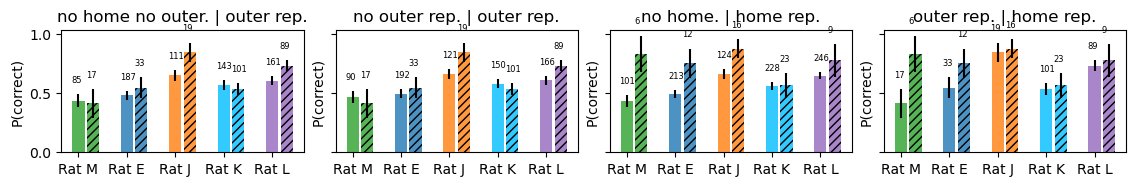

In [67]:
num_of_panels = 4
draw_text = True
fig, axes = plt.subplots(1, num_of_panels, figsize=(3 * num_of_panels, 2.5), sharey = True)
axes = axes.reshape((1,-1))

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]#["molly","eliot","julio","lewis","klein"]#["molly","lewis","julio","klein"]

annotations = {(i,j):[] for j in range(3) for i in range(1)}

for animal in animals:

    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward,
     remote_theta, long_theta,
     theta, theta_home, remote_theta_outer,
     com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta"], loaded_data["long_theta"],
         loaded_data["theta"], loaded_data["remote_theta_home"], loaded_data["remote_theta_outer"],
        loaded_data["com_num"], loaded_data["learning_flag"])
    
    print(f"Rat {animal[0].upper()}: {np.sum(np.array(remote_theta)[np.array(theta_home) > 0])/np.sum(remote_theta)} remote trials with home.")


    reward_nonremote_theta = np.array(reward)[1-np.array(remote_theta) > 0]
    
    reward_remote_outer = np.array(reward)[np.array(remote_theta_outer) > 0]
    reward_no_remote_outer = np.array(reward)[np.array(remote_theta_outer) == 0]
    
    reward_home = np.array(reward)[np.array(theta_home) > 0]
    reward_no_home = np.array(reward)[np.array(theta_home) == 0]
    
    axes_row_ind = 0
    # axis 0: nontheta vs long theta
    ax = axes[axes_row_ind,0]
    data1, data2 = reward_nonremote_theta, reward_remote_outer
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal,
                             draw_text = True)
    if pvalue <= 0.05:
        annotations[(axes_row_ind,2)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
        
    # axis 1: nontheta vs theta
    ax = axes[axes_row_ind,1]
    data1, data2 = reward_no_remote_outer, reward_remote_outer
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal,
                              draw_text = True)
    #_, pvalue = ranksums(data1, data2)
    if pvalue <= 0.05:
        annotations[(axes_row_ind,0)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
    
    # axis 2: nontheta vs theta
    ax = axes[axes_row_ind,2]
    data1, data2 = reward_no_home, reward_home
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal,
                             draw_text = True)
    #_, pvalue = ranksums(data1, data2, "less")
    print("pvalue", animal, "row number", axes_row_ind, pvalue)
    if pvalue <= 0.05:
        annotations[(axes_row_ind,1)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    # axis 3: nontheta vs long theta
    ax = axes[axes_row_ind,3]
    data1, data2 = reward_remote_outer, reward_home
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal,
                             draw_text = True)
    if pvalue <= 0.05:
        annotations[(axes_row_ind,2)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    animal_ind += 1


for i in range(1):
    for j in range(4):
        ax = axes[i,j]
        #starbars.draw_annotation(annotations[i,j],ax)
        
        
        ax.set_xticks(np.arange(len(animals)));
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
        ax.set_ylabel("P(correct)")
        #ax.set_xlim([-1,len(animals) + 1]);
        #ax.set_ylim([0.3,0.85]);

        if j == 1:
            title = "no outer rep. | outer rep."
        elif j == 2:
            title = "no home. | home rep."
        elif j == 3:
            title = "outer rep. | home rep."
        elif j == 0:
            title = "no home no outer. | outer rep."

        
        ax.set_title(title)
        
        
plt.subplots_adjust(hspace=0.5, wspace = 1)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

#file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_draw_test{draw_text}.pdf"
#fig.savefig(file_path, format="pdf", bbox_inches="tight")

#plt.savefig(f'extra_correctness_by_theta.pdf',dpi=300,bbox_inches='tight')

### Fold change plots by rats

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Optimization terminated successfully.
         Current function value: 0.678820
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.679880
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.688790
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671703
         Iterations 5
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Optimization terminated successfully.
         Current function value: 0.687644
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.689191
         Iterations 4
Optimization terminated successfully.
         Current function 

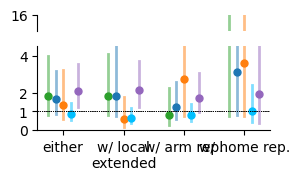

In [91]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 1.5),
                               gridspec_kw={'height_ratios': [0.1,0.5]},
                               sharex = True)

animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:

    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num) = (
        loaded_data["reward"], loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],loaded_data["com_num"])
    learning = loaded_data["learning_flag"]
    max_distance = loaded_data["max_distance"]
    remote_home = loaded_data["remote_theta_home"]
    remote_outer = loaded_data["remote_theta_outer"]

    feature_dict1 = {"remote or local extended": theta}

    X = pd.DataFrame(feature_dict1)
    X = sm.add_constant(X)
    y = reward

    """a) Mixed Logistic Effect"""
    logistic_model = sm.Logit(y, X)
    logistic_result1 = logistic_model.fit()
    params1, coef_names1, coef_est1, pvalues1, CI1 = model2numbers(logistic_result1)
    coef_est1 = np.exp(coef_est1)
    CI1 = np.exp(CI1)

    """b) Mixed Logistic Effect"""
    feature_dict2 = {"local extended": long_theta}
    X = pd.DataFrame(feature_dict2)
    X = sm.add_constant(X)
    y = reward
    logistic_model = sm.Logit(y, X)
    logistic_result2 = logistic_model.fit()
    params2, coef_names2, coef_est2, pvalues2, CI2 = model2numbers(logistic_result2)
    coef_est2 = np.exp(coef_est2)
    CI2 = np.exp(CI2)

    """c) Mixed Logistic Effect"""
    feature_dict3 = {"outer arm": remote_outer}
    X = pd.DataFrame(feature_dict3)
    X = sm.add_constant(X)
    y = reward
    logistic_model = sm.Logit(y, X)
    logistic_result3 = logistic_model.fit()
    params3, coef_names3, coef_est3, pvalues3, CI3 = model2numbers(logistic_result3)
    coef_est3 = np.exp(coef_est3)
    CI3 = np.exp(CI3)

    """c) Mixed Logistic Effect"""
    feature_dict4 = {"home arm": remote_home}
    X = pd.DataFrame(feature_dict4)
    X = sm.add_constant(X)
    y = reward
    logistic_model = sm.Logit(y, X)
    logistic_result4 = logistic_model.fit()
    params4, coef_names4, coef_est4, pvalues4, CI4 = model2numbers(logistic_result4)
    coef_est4 = np.exp(coef_est4)
    CI4 = np.exp(CI4)

    # either
    dt = 0.4
    dx=0.05
    for axes in [ax1, ax2]:
        
        xloc = animal_ind*dx
        axes.scatter(xloc, coef_est1[0], marker = ".", s = 100, color = color_by_rat[animal])
        axes.plot([xloc, xloc], [CI1[0], CI1[1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])
    
        # with local
        xloc = animal_ind*dx + dt
        axes.scatter(xloc, coef_est2[0], marker = ".", s = 100, color = color_by_rat[animal])
        axes.plot([xloc, xloc], [CI2.iloc[0][0], CI2.iloc[0][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])
    
        # with remote
        xloc = animal_ind*dx + dt * 2
        axes.scatter(xloc, coef_est3[0], marker = ".", s = 100, color = color_by_rat[animal])
        axes.plot([xloc, xloc], [CI3.iloc[0][0], CI3.iloc[0][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])

        # with remote
        xloc = animal_ind*dx + dt * 3
        axes.scatter(xloc, coef_est4[0], marker = ".", s = 100, color = color_by_rat[animal])
        axes.plot([xloc, xloc], [CI4.iloc[0][0], CI4.iloc[0][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])
    
        # axhline
        axes.axhline(1,-0.1,2.1, color = 'k', linestyle = "dotted", linewidth = 0.5)
    
        

        axes.set_yticks([0, 1, 2, 4, 8, 16])
        axes.spines[['right', 'top']].set_visible(False)

    ax1.set_ylim(12, 16)  # outliers only
    ax2.set_ylim(0, 4.5)  # most of the data

    ax2.set_xticks([dx*2, dx*2+dt, dx*2+dt*2, dx*2+dt*3])
    ax2.set_xticklabels(["either", "w/ local\nextended", "w/ arm rep.", "w/ home rep."])
    
    # hide the spines between ax and ax2
    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.get_xaxis().set_visible(False)
    #ax1.set_xticks([])
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    #ax2.xaxis.tick_bottom()

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d)], markersize=12,
                   linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
        
    animal_ind += 1

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_stats.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### merge all rats

In [46]:
animals = ["molly","eliot","lewis","julio","klein"]

animal_ind = 0

GLM_xy = []
for animal in animals:
    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num) = (
        loaded_data["reward"], loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],loaded_data["com_num"])
    learning = loaded_data["learning_flag"]
    max_distance = loaded_data["max_distance"]
    thetaxlearning = np.array(learning) * np.array(loaded_data["theta"])
    remotexlearning = np.array(learning) * np.array(loaded_data["remote_theta"])
    longxlearning = np.array(learning) * np.array(loaded_data["long_theta"])
    remote_home = loaded_data["remote_theta_home"]
    remote_outer = loaded_data["remote_theta_outer"]

    animal_category = [a == animal for a in animals]
    for ind in range(len(reward)):
        GLM_xy.append(animal_category + [
            com_num[ind],
            theta[ind], long_theta[ind], remote_theta[ind], remote_home[ind], remote_outer[ind],
            learning[ind],
            thetaxlearning[ind],
            longxlearning[ind],
            remotexlearning[ind],
            max_distance[ind],
            reward[ind]])

GLM_xy = np.array(GLM_xy)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.2_sd6_figure4Fa


#### a) either remote or local extended

Optimization terminated successfully.
         Current function value: 0.663993
         Iterations 5
===== start ===== 
Start printing 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  978
Model:                          Logit   Df Residuals:                      972
Method:                           MLE   Df Model:                            5
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.02500
Time:                        09:24:25   Log-Likelihood:                -649.39
converged:                       True   LL-Null:                       -666.04
Covariance Type:            nonrobust   LLR p-value:                 3.273e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1170   4.35e+06   2.69e-08      1.000

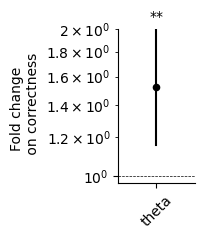

In [47]:
# 4. Create the bar graph using matplotlib
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["theta"] = GLM_xy[:,(len(animals)+1)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

logistic_model = sm.Logit(y, X)
logit_result1 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("Start printing \n Mixed Logistics \n",logit_result1.summary())
print("===== end ===== ")


fig, axes = plt.subplots(1,1,figsize=(1, 2))

#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')


axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
#axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,2])
#axes.set_yticks([0.1, 1, 10])

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')


# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_gross_theta_GLM_trialresult.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [137]:
np.exp(0.3707), np.exp(0.095), np.exp(0.646)

(1.4487483836713462, 1.099658855126103, 1.9078939696124533)

#### b) local extended, remote or home

In [48]:
## Model 2: remote theta or long theta
com1 = GLM_xy[:,len(animals)] #> 0# 1
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["local extended"] = GLM_xy[:,(len(animals)+2)]
feature_dict["arm rep."] = np.logical_and(GLM_xy[:,(len(animals)+3)], 1-GLM_xy[:,(len(animals)+4)]).astype("int")
feature_dict["home rep. "] = GLM_xy[:,(len(animals)+4)]
#feature_dict["max distance"] = GLM_xy[:,-2]

#feature_dict["remote theta x com num"] = com1 * GLM_xy[:,(len(animals)+3)] #GLM_xy[:,(len(animals)+7)]
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("\n \n Mixed Logistics \n",logistic_result2.summary())
print("===== end ===== ")


Optimization terminated successfully.
         Current function value: 0.662826
         Iterations 5
===== start ===== 

 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  978
Model:                          Logit   Df Residuals:                      970
Method:                           MLE   Df Model:                            7
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.02672
Time:                        09:24:46   Log-Likelihood:                -648.24
converged:                       True   LL-Null:                       -666.04
Covariance Type:            nonrobust   LLR p-value:                 8.671e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1300   9.43e+06   1.38e-08      1.000 

In [139]:
np.exp(0.7232), np.exp(0.14), np.exp(1.306)

(2.061017926844913, 1.1502737988572271, 3.691378627258037)

3.0 0.03


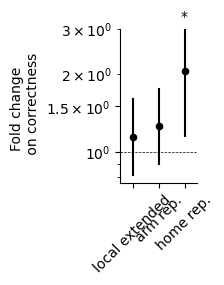

In [131]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(1, 2))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result2)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes.scatter(coef_names, coef_est, color = "k", s = 20)
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')


axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
#axes.set_title("logistic regression")
axes.set_ylabel("Fold change \n on correctness")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes.set_yscale('log') 
axes.set_xlim([-0.5,2.5])
axes.set_ylim([0,3])
axes.set_yticks([1, 1.5])

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')


# theta_point_est = coef_pd.loc["local extended"]
# theta_CI = CI.loc["local extended"]
# print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/extra_correctness_theta_GLM_by_content_trialresult.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [97]:
np.exp(0.72)

2.0544332106438876

#### c) home alone, home + other arms, home + current arm

In [ ]:
GLM_xy.append(animal_category + [
            com_num[ind],
            theta[ind], long_theta[ind], remote_theta[ind], remote_home[ind], remote_outer[ind],
            learning[ind],
            thetaxlearning[ind],
            longxlearning[ind],
            remotexlearning[ind],
            max_distance[ind],
            reward[ind]])

In [58]:

home_alone = np.logical_and(
    np.logical_and(GLM_xy[:,(len(animals)+5)] == 0, GLM_xy[:,(len(animals)+2)] == 0),
    GLM_xy[:,(len(animals)+4)] > 0
)

home_other_arms = np.logical_and(GLM_xy[:,(len(animals)+4)] > 0, GLM_xy[:,(len(animals)+5)] > 0)

home_current_arm = np.logical_and(GLM_xy[:,(len(animals)+4)] > 0, GLM_xy[:,(len(animals)+2)] > 0)

home_rows = np.sum(GLM_xy[:,(len(animals)+4)] > 0)
total_rows = np.sum(GLM_xy[:,(len(animals)+4)] >= 0)
print(f"# of trials with home representation: {home_rows} out of {total_rows} trials.")

feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["home alone"] = home_alone.astype("int")
feature_dict["home w others"] = home_other_arms.astype("int")
feature_dict["home w current"] = home_current_arm.astype("int")


#feature_dict["remote theta x com num"] = com1 * GLM_xy[:,(len(animals)+3)] #GLM_xy[:,(len(animals)+7)]
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("\n \n Mixed Logistics \n",logistic_result2.summary())
print("===== end ===== ")

# of trials with home representation: 66 out of 978 trials.
Optimization terminated successfully.
         Current function value: 0.662287
         Iterations 5
===== start ===== 

 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  978
Model:                          Logit   Df Residuals:                      970
Method:                           MLE   Df Model:                            7
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.02751
Time:                        09:43:30   Log-Likelihood:                -647.72
converged:                       True   LL-Null:                       -666.04
Covariance Type:            nonrobust   LLR p-value:                 5.479e-06
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------